# **Домашнее задание к семинарам 10-11 (HW10-11)**

**Тема:** компьютерное зрение в PyTorch. Часть S10: CNN, аугментации, transfer learning на ResNet. Часть S11: детекция или сегментация, корректная визуализация и базовая валидация.

**Цель:**

Закрепить:
- переход от табличных/плоских представлений к изображениям и сверточным сетям;
- базовые практики компьютерного зрения в PyTorch: Dataset/DataLoader, transforms, CNN, transfer learning;
- различие между задачами классификации, детекции и сегментации;
- корректный выбор метрик под задачу;
- аккуратное оформление результатов: один ноутбук, короткий отчёт, артефакты эксперимента.

In [ ]:
BASE_PATH = "./"

ARTIFACTS_DIR = os.path.join(BASE_PATH, "artifacts")
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Base path:", BASE_PATH)

runs_path = os.path.join(ARTIFACTS_DIR, "runs.csv")

if not os.path.exists(runs_path):
    df = pd.DataFrame(columns=[
        "experiment_id", "task", "dataset", "seed",
        "model_summary", "optimizer", "lr", "epochs_trained",
        "best_val_accuracy", "test_accuracy",
        "precision", "recall", "mean_iou", "notes"
    ])
    df.to_csv(runs_path, index=False)

print("runs.csv ready")

runs.csv ready


### **1. Импорты, seed и устройство**

#### 1.1. Импортировать библиотеки: torch, torchvision, numpy, matplotlib (и всё, что нужно по делу).

In [35]:
# Импорты
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as T
from torchvision import datasets, models

from torch.utils.data import DataLoader, random_split

#### 1.2. Зафиксировать seed (минимум torch.manual_seed, желательно также numpy).

In [8]:
# Seed
SEED = 666

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### 1.3.  Определить устройство (cuda при наличии, иначе cpu) и убедиться, что и модель, и батчи переводятся на один device.

In [18]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cpu


### **2. Данные и DataLoader**

#### 2.1. Загрузить выбранный классификационный датасет для части A.

In [21]:
DATA_DIR = "./data"

full_train_dataset = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=None
)

test_dataset = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=None
)

print("Train (full):", len(full_train_dataset))
print("Test:", len(test_dataset))

Train (full): 5000
Test: 8000


#### 2.2. Подготовить transforms для части A:
- базовый transform для CNN;
- transform с аугментациями;
- preprocessing для ResNet с pretrained weights.

In [22]:
DATA_DIR = "./data"

# базовый transform
transform_base = T.Compose([
    T.Resize((96, 96)),
    T.ToTensor()
])

# аргументация
transform_aug = T.Compose([
    T.Resize((96, 96)),
    T.RandomHorizontalFlip(),
    T.RandomCrop(96, padding=4),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor()
])

# preprocessing
weights = models.ResNet18_Weights.DEFAULT
transform_resnet = weights.transforms()

#### 2.3. Создать DataLoader для train/val/test в части A.

In [23]:
full_train_dataset.transform = transform_base
test_dataset.transform = transform_base

# деление train (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# DataLoader
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4000
Val: 1000
Test: 8000


#### 2.4. Загрузить выбранный датасет для части B.

In [24]:
transform_seg = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

target_transform_seg = T.Compose([
    T.Resize((128, 128)),
    T.PILToTensor()
])

seg_dataset = datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=transform_seg,
    target_transform=target_transform_seg
)

print("Segmentation dataset size:", len(seg_dataset))

100%|██████████| 792M/792M [00:37<00:00, 21.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.0MB/s]


Segmentation dataset size: 3680


#### 2.5. Показать sanity-check и примеры изображений для обеих частей.

##### 2.5.1. Часть A

In [25]:
images, labels = next(iter(train_loader))

print("x.shape:", images.shape)
print("y.shape:", labels.shape)

x.shape: torch.Size([64, 3, 96, 96])
y.shape: torch.Size([64])


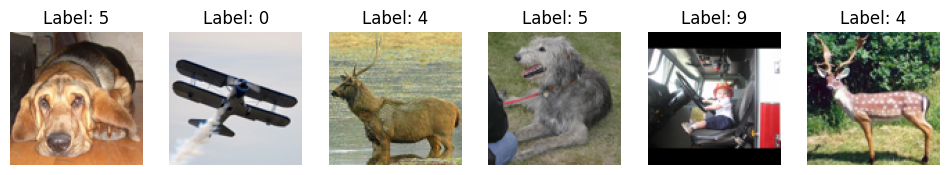

In [26]:
def show_images(images, labels, n=6):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = images[i].permute(1, 2, 0)
        plt.imshow(img)
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

show_images(images, labels)

##### 2.5.2. Часть B

In [27]:
img, mask = seg_dataset[0]

print("Seg image shape:", img.shape)
print("Seg mask shape:", mask.shape)

Seg image shape: torch.Size([3, 128, 128])
Seg mask shape: torch.Size([1, 128, 128])


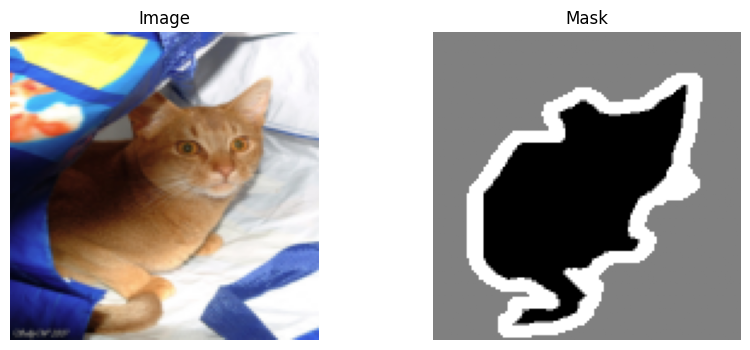

In [28]:
def show_segmentation(img, mask):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.show()

show_segmentation(img, mask)

### **3. Базовые функции обучения и оценки**

Функция обучения и оценки

In [29]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [30]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

Общая функция обучения

In [31]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

        print(f"Epoch {epoch+1}: "
              f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
              f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    return best_model_state, best_val_acc, history

#### 3.1. Часть A. Эксперименты C1–C4

##### 3.1.1. Простая CNN (для C1 и C2)

In [32]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

##### 3.1.2. C1 (simple-cnn-base)

In [33]:
model_c1 = SimpleCNN()

best_state_c1, best_val_c1, hist_c1 = train_model(
    model_c1, train_loader, val_loader, epochs=10
)

Epoch 1: train_loss=2.1465, val_loss=2.0123, train_acc=0.2082, val_acc=0.2380
Epoch 2: train_loss=1.9040, val_loss=1.8587, train_acc=0.2747, val_acc=0.2910
Epoch 3: train_loss=1.8315, val_loss=1.7950, train_acc=0.2965, val_acc=0.3100
Epoch 4: train_loss=1.7829, val_loss=1.7851, train_acc=0.3023, val_acc=0.3090
Epoch 5: train_loss=1.7344, val_loss=1.7633, train_acc=0.3100, val_acc=0.3080
Epoch 6: train_loss=1.7190, val_loss=1.6744, train_acc=0.3245, val_acc=0.3630
Epoch 7: train_loss=1.6917, val_loss=1.6763, train_acc=0.3407, val_acc=0.3340
Epoch 8: train_loss=1.6628, val_loss=1.6443, train_acc=0.3432, val_acc=0.3540
Epoch 9: train_loss=1.6236, val_loss=1.6241, train_acc=0.3598, val_acc=0.3540
Epoch 10: train_loss=1.6047, val_loss=1.6087, train_acc=0.3695, val_acc=0.3670


##### 3.1.3. C2 (simple-cnn-aug)

In [34]:
full_train_dataset.transform = transform_aug

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader_aug = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_aug = DataLoader(val_dataset, batch_size=64)

model_c2 = SimpleCNN()

best_state_c2, best_val_c2, hist_c2 = train_model(
    model_c2, train_loader_aug, val_loader_aug, epochs=10
)

Epoch 1: train_loss=2.2382, val_loss=2.1137, train_acc=0.1552, val_acc=0.2090
Epoch 2: train_loss=2.0239, val_loss=1.9674, train_acc=0.2372, val_acc=0.2600
Epoch 3: train_loss=1.9208, val_loss=1.8999, train_acc=0.2732, val_acc=0.2630
Epoch 4: train_loss=1.8570, val_loss=1.8485, train_acc=0.2923, val_acc=0.2550
Epoch 5: train_loss=1.8095, val_loss=1.7536, train_acc=0.2913, val_acc=0.3080
Epoch 6: train_loss=1.7528, val_loss=1.7382, train_acc=0.3165, val_acc=0.3080
Epoch 7: train_loss=1.7230, val_loss=1.7315, train_acc=0.3195, val_acc=0.3240
Epoch 8: train_loss=1.6902, val_loss=1.6799, train_acc=0.3380, val_acc=0.3210
Epoch 9: train_loss=1.6704, val_loss=1.6546, train_acc=0.3468, val_acc=0.3510
Epoch 10: train_loss=1.6569, val_loss=1.7035, train_acc=0.3550, val_acc=0.3330


##### 3.1.4. C3 (resnet18-head-only)

In [36]:
model_c3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_c3.parameters():
    param.requires_grad = False

model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)

best_state_c3, best_val_c3, hist_c3 = train_model(
    model_c3, train_loader, val_loader, epochs=5, lr=1e-3
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]


Epoch 1: train_loss=1.5799, val_loss=1.0938, train_acc=0.4773, val_acc=0.6820
Epoch 2: train_loss=0.9524, val_loss=0.8900, train_acc=0.6975, val_acc=0.7270
Epoch 3: train_loss=0.8338, val_loss=0.8252, train_acc=0.7362, val_acc=0.7550
Epoch 4: train_loss=0.7432, val_loss=0.7811, train_acc=0.7582, val_acc=0.7510
Epoch 5: train_loss=0.7266, val_loss=0.7438, train_acc=0.7672, val_acc=0.7630


##### 3.1.5. C4 (resnet18-finetune)


In [37]:
model_c4 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for name, param in model_c4.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)

best_state_c4, best_val_c4, hist_c4 = train_model(
    model_c4, train_loader, val_loader, epochs=5, lr=1e-4
)

Epoch 1: train_loss=1.0986, val_loss=0.5853, train_acc=0.6260, val_acc=0.8040
Epoch 2: train_loss=0.4566, val_loss=0.4764, train_acc=0.8530, val_acc=0.8440
Epoch 3: train_loss=0.3133, val_loss=0.3970, train_acc=0.9030, val_acc=0.8720
Epoch 4: train_loss=0.1996, val_loss=0.3999, train_acc=0.9415, val_acc=0.8670
Epoch 5: train_loss=0.1532, val_loss=0.4193, train_acc=0.9600, val_acc=0.8610


##### 3.1.6. Выбор лучшей модели + test

In [38]:
best_model = model_c1
best_state = best_state_c1
best_val = best_val_c1

for model, state, val in [
    (model_c2, best_state_c2, best_val_c2),
    (model_c3, best_state_c3, best_val_c3),
    (model_c4, best_state_c4, best_val_c4)
]:
    if val > best_val:
        best_model = model
        best_state = state
        best_val = val

best_model.load_state_dict(best_state)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion)

print("Best val acc:", best_val)
print("Test acc:", test_acc)

Best val acc: 0.872
Test acc: 0.86425


#### 3.2. Часть B. Segmentation track

##### 3.2.1. Модель

In [39]:
model_seg = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")
model_seg = model_seg.to(device)
model_seg.eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 144MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

##### 3.2.2. Предсказание и визуализация

In [40]:
def predict_mask(model, img):
    with torch.no_grad():
        out = model(img.unsqueeze(0).to(device))["out"]
        pred = out.argmax(1).squeeze().cpu()
    return pred

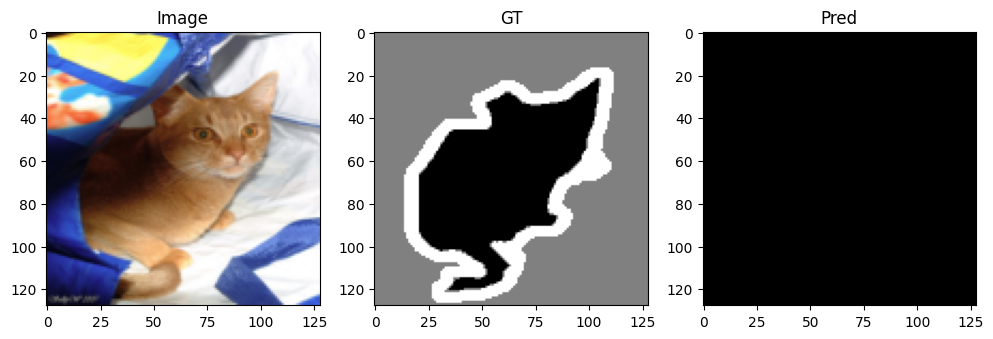

In [41]:
img, mask = seg_dataset[0]
pred = predict_mask(model_seg, img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("GT")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Pred")

plt.show()

##### 3.2.3. Метрика mean_iou

In [42]:
def compute_iou(pred, target):
    pred = pred > 0
    target = target > 0

    intersection = (pred & target).sum().item()
    union = (pred | target).sum().item()

    return intersection / union if union > 0 else 0

##### 3.2.4. Два режима (V1, V2)

In [43]:
ious_v1 = []
ious_v2 = []

for i in range(20):
    img, mask = seg_dataset[i]
    pred = predict_mask(model_seg, img)

    iou1 = compute_iou(pred, mask.squeeze())

    pred2 = pred.clone()
    pred2[pred2 < 1] = 0

    iou2 = compute_iou(pred2, mask.squeeze())

    ious_v1.append(iou1)
    ious_v2.append(iou2)

print("Mean IoU V1:", np.mean(ious_v1))
print("Mean IoU V2:", np.mean(ious_v2))

Mean IoU V1: 0.2530609130859375
Mean IoU V2: 0.2530609130859375


### **4. Артефакты**

In [ ]:
ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [54]:
import pandas as pd

columns = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes"
]

runs = []

runs.append(["C1","classification","STL10",SEED,"SimpleCNN","Adam",1e-3,10,best_val_c1,None,None,None,None,"base"])
runs.append(["C2","classification","STL10",SEED,"SimpleCNN","Adam",1e-3,10,best_val_c2,None,None,None,None,"augmentation"])
runs.append(["C3","classification","STL10",SEED,"ResNet18","Adam",1e-3,5,best_val_c3,None,None,None,None,"head-only"])
runs.append(["C4","classification","STL10",SEED,"ResNet18","Adam",1e-4,5,best_val_c4,test_acc,None,None,None,"finetune"])

runs.append(["V1","segmentation","OxfordIIITPet",SEED,"DeepLabV3",None,None,None,None,None,None,None,np.mean(ious_v1),"baseline"])
runs.append(["V2","segmentation","OxfordIIITPet",SEED,"DeepLabV3",None,None,None,None,None,None,None,np.mean(ious_v2),"postprocessing"])

df = pd.DataFrame(runs, columns=columns)
df.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)

df.head()

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,666,SimpleCNN,Adam,0.0010,10.0,0.367,NaN,None,None,NaN,base
1,C2,classification,STL10,666,SimpleCNN,Adam,0.0010,10.0,0.351,NaN,None,None,NaN,augmentation
2,C3,classification,STL10,666,ResNet18,Adam,0.0010,5.0,0.763,NaN,None,None,NaN,head-only
3,C4,classification,STL10,666,ResNet18,Adam,0.0001,5.0,0.872,0.86425,None,None,NaN,finetune
4,V1,segmentation,OxfordIIITPet,666,DeepLabV3,None,NaN,NaN,NaN,NaN,None,None,0.253061,baseline


In [55]:
torch.save(best_state, os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))

In [56]:
config = {
    "dataset": "STL10",
    "model": str(best_model.__class__.__name__),
    "input_size": [3, 96, 96],
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "epochs": 10,
    "seed": SEED,
    "transforms": {
        "base": "Resize(96,96) + ToTensor",
        "aug": "RandomCrop + Flip + ColorJitter",
        "resnet": "ImageNet normalization"
    }
}

with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(config, f, indent=4)

In [57]:
def plot_history(history, filename):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.legend()
    plt.title("Accuracy")

    plt.savefig(filename)
    plt.close()

# история лучшей модели
best_history = hist_c1
if best_val == best_val_c2:
    best_history = hist_c2
elif best_val == best_val_c3:
    best_history = hist_c3
elif best_val == best_val_c4:
    best_history = hist_c4

plot_history(
    best_history,
    os.path.join(FIGURES_DIR, "classification_curves_best.png")
)

In [58]:
vals = [best_val_c1, best_val_c2, best_val_c3, best_val_c4]
labels = ["C1","C2","C3","C4"]

plt.figure()
plt.bar(labels, vals)
plt.title("Best Val Accuracy Comparison")
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"))
plt.close()

In [59]:
def show_augmentations(dataset, n=6):
    plt.figure(figsize=(12,4))
    for i in range(n):
        img, _ = dataset[i]
        plt.subplot(1,n,i+1)
        plt.imshow(img.permute(1,2,0))
        plt.axis("off")
    plt.savefig(os.path.join(FIGURES_DIR, "augmentations_preview.png"))
    plt.close()

show_augmentations(full_train_dataset)

In [60]:
plt.figure(figsize=(12,6))

for i in range(3):
    img, mask = seg_dataset[i]
    pred = predict_mask(model_seg, img)

    plt.subplot(3,3,i*3+1)
    plt.imshow(img.permute(1,2,0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(3,3,i*3+2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("GT")
    plt.axis("off")

    plt.subplot(3,3,i*3+3)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred")
    plt.axis("off")

plt.savefig(os.path.join(FIGURES_DIR, "segmentation_examples.png"))
plt.close()

In [62]:
means = [np.mean(ious_v1), np.mean(ious_v2)]
labels = ["V1", "V2"]

plt.figure()
plt.bar(labels, means)
plt.title("Mean IoU Comparison")
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"))
plt.close()